In [1]:
import pandas as pd

file_path = "data/raw/population_communes.xlsx"
df = pd.read_excel(file_path)

# Vérifier les premières lignes
print(df.head())
print(df.info())



   objectid  reg dep    cv codgeo                 libgeo  p13_pop  p14_pop  \
0    115658   52  85  8502  85062            Châteauneuf    968.0    993.0   
1    115659   26  58  5808  58300                   Urzy   1839.0   1835.0   
2    115660   43  70  7012  70137  Chassey-lès-Montbozon    218.0    217.0   
3    115661   21  51  5123  51649      Vitry-le-François  13174.0  13144.0   
4    115662   11  78  7811  78638         Vaux-sur-Seine   4749.0   4715.0   

   p15_pop  p16_pop  p17_pop  p18_pop  p19_pop  p20_pop  p21_pop  
0   1013.0   1027.0     1056   1085.0   1114.0   1118.0   1134.0  
1   1828.0   1802.0     1775   1749.0   1746.0   1747.0   1742.0  
2    216.0    215.0      217    215.0    215.0    220.0    225.0  
3  12805.0  12552.0    12133  11743.0  11376.0  11458.0  11454.0  
4   4788.0   4857.0     4927   4929.0   5010.0   5020.0   5083.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34995 entries, 0 to 34994
Data columns (total 15 columns):
 #   Column    Non-N

In [2]:
df.columns


Index(['objectid', 'reg', 'dep', 'cv', 'codgeo', 'libgeo', 'p13_pop',
       'p14_pop', 'p15_pop', 'p16_pop', 'p17_pop', 'p18_pop', 'p19_pop',
       'p20_pop', 'p21_pop'],
      dtype='object')

In [3]:
# Sélection des colonnes utiles
df_clean = df[["codgeo", "p21_pop"]].copy()

# Renommage clair des colonnes
df_clean.columns = ["code_commune", "population"]

# Vérification
print(df_clean.head())
print(df_clean.info())


  code_commune  population
0        85062      1134.0
1        58300      1742.0
2        70137       225.0
3        51649     11454.0
4        78638      5083.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34995 entries, 0 to 34994
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   code_commune  34995 non-null  object 
 1   population    34969 non-null  float64
dtypes: float64(1), object(1)
memory usage: 546.9+ KB
None


In [4]:
# Vérifier les valeurs manquantes
df_clean.isna().sum()


code_commune     0
population      26
dtype: int64

In [5]:
# Suppression des communes sans population
df_clean = df_clean.dropna(subset=["population"])

# Vérification
df_clean.isna().sum()


code_commune    0
population      0
dtype: int64

In [6]:
# Sauvegarde finale des données propres
df_clean.to_csv(
    "data/processed/population_communes_clean.csv",
    index=False
)

print("✔️ Fichier nettoyé sauvegardé (sans valeurs manquantes)")


✔️ Fichier nettoyé sauvegardé (sans valeurs manquantes)


In [7]:
import pandas as pd

df_pop = pd.read_csv("data/processed/population_communes_clean.csv")

df_pop.head()


,code_commune,population
0,85062,1134.0
1,58300,1742.0
2,70137,225.0
3,51649,11454.0
4,78638,5083.0


In [8]:
df_pop["population"].describe()


count     34969.000000
mean       1927.597701
std        8737.679677
min           0.000000
25%         197.000000
50%         458.000000
75%        1167.000000
max      504078.000000
Name: population, dtype: float64

In [9]:
# Quelques quantiles clés
df_pop["population"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])


0.01       32.00
0.05       69.00
0.25      197.00
0.50      458.00
0.75     1167.00
0.95     6349.40
0.99    27906.56
Name: population, dtype: float64

In [10]:
df_pop.sort_values("population", ascending=False).head(10)


,code_commune,population
30718,31555,504078.0
18418,06088,348085.0
1413,44109,323204.0
13755,34172,302454.0
27671,67482,291313.0
391,33063,261804.0
9934,59350,236710.0
33122,75115,227746.0
16282,35238,225081.0
11971,75120,189805.0


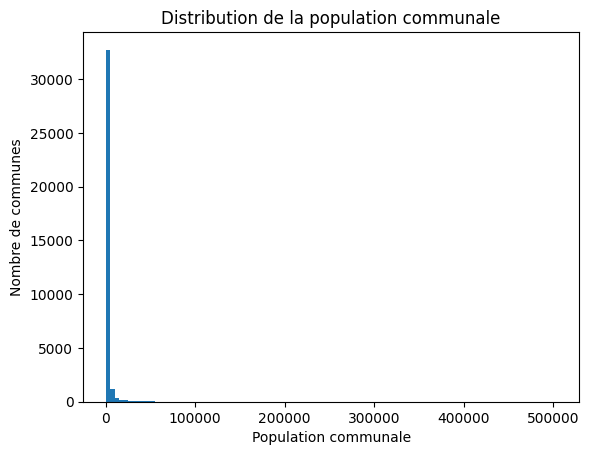

In [11]:
import matplotlib.pyplot as plt

plt.hist(df_pop["population"], bins=100)
plt.xlabel("Population communale")
plt.ylabel("Nombre de communes")
plt.title("Distribution de la population communale")
plt.show()
